# Laboratorio 7: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2024</strong></center>


### Cuerpo Docente:

- Profesores: Ignacio Meza, Sebastián Tinoco
- Auxiliar: Eduardo Moya
- Ayudantes: Nicolás Ojeda, Melanie Peña, Valentina Rojas

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Angelo León
- Nombre de alumno 2: Damián De Aguiar

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/damiatus/labPrograCientifica)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

### Reglas:

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.
- Código que no se pueda ejecutar, no será revisado.



### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy
  * Precision
  * Recall
  * F1 score

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera.  
  * Detección de enfermedades altamente contagiosas.
  * Aprobación de créditos de alto riesgo.
  * Detección de crímenes.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]


**Respuesta:**

*Escriba su respuesta aquí*

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://i.ibb.co/61L8z0w/renacin-by-volframio-dcirf4l-fullview.jpg"
" width="400">
</p>



Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [1]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

Ignorando conexión drive-colab


In [2]:
import pandas as pd

data = pd.read_csv('stats_players.csv')
data

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17583,Adam Dunbar,Republic of Ireland,NaN,Sub,183,82,Right,19,Medium / Medium,1,...,27,56,14,16,13,13,11,13,15,12
17584,Dylan McGoey,Republic of Ireland,NaN,Sub,185,80,Right,19,Medium / Medium,2,...,28,53,12,17,12,11,12,13,16,12
17585,Tommy Ouldridge,England,NaN,Res,173,61,Right,18,High / Medium,2,...,54,61,41,44,28,42,35,36,42,37
17586,Mark Foden,Scotland,NaN,Sub,180,80,Right,21,Medium / Medium,3,...,34,48,15,23,14,12,13,12,24,12


In [3]:
data.columns

Index(['Name', 'Nationality', 'National_Position', 'Club_Position', 'Height',
       'Weight', 'Preffered_Foot', 'Age', 'Work_Rate', 'Weak_foot',
       'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle',
       'Standing_Tackle', 'Aggression', 'Reactions', 'Interceptions', 'Vision',
       'Composure', 'Crossing', 'Short_Pass', 'Long_Pass', 'Acceleration',
       'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping',
       'Heading', 'Shot_Power', 'Finishing', 'Long_Shots', 'Curve',
       'Freekick_Accuracy', 'Penalties', 'Volleys'],
      dtype='object')

## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

In [4]:
# 1- label
data['label'] = data['National_Position'].notna().astype(int)
# 2- Ejemplos por clase:
ejemplos = data['label'].value_counts()
print(ejemplos)

label
0    16513
1     1075
Name: count, dtype: int64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 3- ColumnTransformer
cat_cols = ['Name', 'Nationality', 'Club_Position', 'Preffered_Foot', 'Work_Rate', 'Weak_foot', 'Skill_Moves']
num_cols = ['Height', 'Weight', 'Age', 'Ball_Control', 'Dribbling', 'Marking', 'Sliding_Tackle', 'Standing_Tackle',
            'Aggression', 'Reactions', 'Interceptions', 'Vision', 'Composure', 'Crossing', 'Short_Pass', 'Long_Pass',
            'Acceleration', 'Speed', 'Stamina', 'Strength', 'Balance', 'Agility', 'Jumping', 'Heading', 'Shot_Power',
            'Finishing', 'Long_Shots', 'Curve', 'Freekick_Accuracy', 'Penalties', 'Volleys']

col_transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

Para las transformaciones, se opto por utilizar para las variables numericas un StandarScaler para que las escalas diferentes de cada columna no tuviesen mayor peso en la clasificacion de label como otras, por ende, mediante esta transformacion, se equipara todo lo numerico.

En el caso de las categoricas, se opto por usar One Hot Encoding para que no hubiesen problemas al procesar las variables categoricas en los modelos de machine learning.

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [6]:
from sklearn.model_selection import train_test_split

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20676305, stratify=y)

In [7]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Pipeline para XGBoost
pipeline_xgboost = Pipeline([
    ('preprocessor', col_transformer),
    ('classifier', XGBClassifier(random_state=20676305))
])

# Pipeline para LightGBM
pipeline_lightgbm = Pipeline([
    ('preprocessor', col_transformer),
    ('classifier', LGBMClassifier(random_state=20676305))
])


# 3- Entrenar modelos
pipeline_xgboost.fit(X_train, y_train)
pipeline_lightgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 752, number of negative: 11559
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2667
[LightGBM] [Info] Number of data points in the train set: 12311, number of used features: 147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061084 -> initscore=-2.732483
[LightGBM] [Info] Start training from score -2.732483


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Height', 'Weight', 'Age',
                                                   'Ball_Control', 'Dribbling',
                                                   'Marking', 'Sliding_Tackle',
                                                   'Standing_Tackle',
                                                   'Aggression', 'Reactions',
                                                   'Interceptions', 'Vision',
                                                   'Composure', 'Crossing',
                                                   'Short_Pass', 'Long_Pass',
                                                   'Acceleration', 'Speed',
                                                   'Stamina', 'Strength',
                                                   'Balance', 'Agility',
                                                   'Jumping', 'Heading',
                                                   'Shot_Power', 'Finishing',
                                                   'Long_Shots', 'Curve',
                                                   'Freekick_Accuracy',
                                                   'Penalties', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Name', 'Nationality',
                                                   'Club_Position',
                                                   'Preffered_Foot',
                                                   'Work_Rate', 'Weak_foot',
                                                   'Skill_Moves'])])),
                ('classifier', LGBMClassifier(random_state=20676305))])

### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

y_pred_xgboost = pipeline_xgboost.predict(X_test)
y_pred_lightgbm = pipeline_lightgbm.predict(X_test)

accuracy_xgboost = accuracy_score(y_test, y_pred_xgboost)
precision_xgboost = precision_score(y_test, y_pred_xgboost, pos_label=1)
recall_xgboost = recall_score(y_test, y_pred_xgboost, pos_label=1)

accuracy_lightgbm = accuracy_score(y_test, y_pred_lightgbm)
precision_lightgbm = precision_score(y_test, y_pred_lightgbm, pos_label=1)
recall_lightgbm = recall_score(y_test, y_pred_lightgbm, pos_label=1)

print("Resultados XGBoost:")
print(f"Accuracy: {accuracy_xgboost}")
print(f"Precision: {precision_xgboost}")
print(f"Recall: {recall_xgboost}")
print("\nResultados LightGBM:")
print(f"Accuracy: {accuracy_lightgbm}")
print(f"Precision: {precision_lightgbm}")
print(f"Recall: {recall_lightgbm}")

# Verificación con classification_report
print("\nReporte de clasificación para XGBoost:")
print(classification_report(y_test, y_pred_xgboost, target_names=['No seleccionado', 'Seleccionado']))

print("\nReporte de clasificación para LightGBM:")
print(classification_report(y_test, y_pred_lightgbm, target_names=['No seleccionado', 'Seleccionado']))

Resultados XGBoost:
Accuracy: 0.9511085844229676
Precision: 0.6815642458100558
Recall: 0.37770897832817335

Resultados LightGBM:
Accuracy: 0.9512980860337313
Precision: 0.7115384615384616
Recall: 0.34365325077399383

Reporte de clasificación para XGBoost:
                 precision    recall  f1-score   support

No seleccionado       0.96      0.99      0.97      4954
   Seleccionado       0.68      0.38      0.49       323

       accuracy                           0.95      5277
      macro avg       0.82      0.68      0.73      5277
   weighted avg       0.94      0.95      0.94      5277


Reporte de clasificación para LightGBM:
                 precision    recall  f1-score   support

No seleccionado       0.96      0.99      0.97      4954
   Seleccionado       0.71      0.34      0.46       323

       accuracy                           0.95      5277
      macro avg       0.84      0.67      0.72      5277
   weighted avg       0.94      0.95      0.94      5277



- Accuracy: Mide el porcentaje total de predicciones acertadas, tanto de las positivas (seleccionado), como de las negativas (no seleccionado).
- Precision: Es la fracción de predicciones correctas entre todas las predicciones positivas. Si se mide mal, significa que el modelo interpreta que muchos jugadores fueron seleccionados cuando no lo fueron.
- Recall: Es la fracción de verdaderos positivos entre todos los jugadores que realmente fueron seleccionados. Si hay pocos ejemplares, significa que el modelo no capta jugadores seleccionados.

Cual metrica es mas importante a la hora de escoger un modelo dependera exclusivamente del contexto del problema a solucionar. En este caso, es preferible no cometer errores al clasificar jugadores como seleccionados o no, por lo que es mas importante la metrica precision. Pese a lo nombrado anteriormente, si se comparan las metricas en general, XGBoost es mejor que LightGBM.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

In [9]:
# 1- Nuevo label
df = data.copy()

ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']

def etiquetar_posicion(posicion):
    if posicion in ataque:
        return 'Ataque'
    elif posicion in central_ataque:
        return 'Central Ataque'
    elif posicion in central:
        return 'Central'
    elif posicion in central_defensa:
        return 'Central Defensa'
    elif posicion in defensa:
        return 'Defensa'
    elif posicion in arquero:
        return 'Arquero'
    else:
        return None

df['label'] = df['Club_Position'].apply(etiquetar_posicion)
df = df.dropna(subset=['label'])

# 2- Contar instancias
conteo_por_clase = df['label'].value_counts()
print(conteo_por_clase)

label
Defensa            1180
Central             907
Arquero             632
Central Ataque      581
Ataque              430
Central Defensa     209
Name: count, dtype: int64


In [38]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=20676305)

pipeline_rf = Pipeline(steps=[
    ('preprocesamiento', col_transformer),
    ('clasificador', RandomForestClassifier())
])

pipeline_rf.fit(X_train, y_train)

y_pred = pipeline_rf.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

        Arquero       1.00      1.00      1.00       190
         Ataque       0.97      0.99      0.98       129
        Central       0.96      0.94      0.95       272
 Central Ataque       1.00      0.95      0.98       174
Central Defensa       1.00      0.48      0.65        63
        Defensa       0.88      0.98      0.93       354

       accuracy                           0.95      1182
      macro avg       0.97      0.89      0.91      1182
   weighted avg       0.95      0.95      0.94      1182



Mediante las metricas se puede apreciar que el modelo resultante es mejor al clasificar ciertas posiciones que otras. Por ejemplo, clasifica a la perfeccion un jugador arquero, pero posee errores en los centrales defensa. Por las metricas, recomendaria su uso para arqueros, atacantes, centrales y centrales atacantes, ya que sus rendimientos son solidos.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionalesm

### 3.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos] 

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**

In [10]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

#Continuar código aquí

# Setup PyCaret
clf = setup(data=df, target='label', session_id=123, fold=5)

,Description,Value
0,Session id,123
1,Target,label
2,Target type,Multiclass
3,Target mapping,"Arquero: 0, Ataque: 1, Central: 2, Central Ataque: 3, Central Defensa: 4, Defensa: 5"
4,Original data shape,"(3939, 40)"
5,Transformed data shape,"(3939, 86)"
6,Transformed train set shape,"(2757, 86)"
7,Transformed test set shape,"(1182, 86)"
8,Numeric features,33
9,Categorical features,6


In [ ]:
#p3.1.1
# Comparar un conjunto de modelos
best_model = compare_models(include = ['et', 'rf', 'dt', 'xgboost', 'lightgbm'], sort='AUC') #No usamos catboost ya que da error y no la contiene

Observamos que el modelo que tiene mayor Precisión , y por tanto, menor taza de falsos positivos es el modelo random forest. Así mismo, si tiempo de ejecucuión es relativamente bajo por lo que se considera el mejor modelo de los entrenados.

In [11]:
#p3.1.2 
rf_model = create_model('rf')  

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9638,0.9994,0.9638,0.9719,0.9658,0.9548,0.9556
1,0.9348,0.9983,0.9348,0.9497,0.9374,0.9187,0.9208
2,0.9546,0.9993,0.9546,0.9611,0.9558,0.9433,0.9444
3,0.9510,0.9984,0.9510,0.9577,0.9523,0.9387,0.9398
4,0.9746,0.9993,0.9746,0.9757,0.9747,0.9681,0.9683
Mean,0.9558,0.9989,0.9558,0.9632,0.9572,0.9447,0.9458
Std,0.0133,0.0005,0.0133,0.0095,0.0126,0.0165,0.0159


*P3.1.2*

DT: Decision Tree
Este modelo lo que hace es dividir los datos en subconjuntos a partir de decisiones binarias. Tiene por objetvo clasificar datos o predecir el valor que tomará una variable. Va dividendo los datos de manera sucesiva en función de los valores de sus características. Tiene por fin reducir métricas como la entropía o el ínidce de Gini asociadas a la calidad de la predicción. Finalmente, el árbol termina en hojas que representan cada una una predicción final, ya sea de la catogoría o su posible valor.

RF: Random Forest.
Este modelo consiste en un conjunto de árboles de decisión entrenados de manera indepedniente entenados con un subconjunto aleatorio de los datos cada arbol creado. La unificación de los árboles se realia a través del promedio de sus resultados o también mediante la clasificaicón de qué árboles funciona mejor. 

ET: Extra Trees. 
Hace refeencia a árboles extremadamente alatorizado, una variante de random forest que intruduce mpas alatorización al crear los árboles. Esto lo hace dividiendo de manera alatoria los datos en cada división. Es más rápido que random forest y por su alatorización reduce la posibilidad de sobreajuste.




In [12]:
#P3.1.3 Como tenemos una semilla de la sesión, podemos correr denuevo estos modelos y darán el mismo resultado
# Evaluar el modelo de Extra Trees
#print("Evaluando el modelo Extra Trees:")
#evaluate_model(et_model)

# Evaluar el modelo de Random Forest
print("Evaluando el modelo Random Forest:")
evaluate_model(rf_model)

# Evaluar el modelo de Decision Tree
#print("Evaluando el modelo Decision Tree:")
#evaluate_model(dt_model)

# Evaluar el modelo de XGBoost
#print("Evaluando el modelo XGBoost:")
#evaluate_model(xgboost_model)

# Evaluar el modelo de lightgbm
#print("Evaluando el modelo lightgbm:")
#evaluate_model(lightgbm_model)

# Evaluar el modelo de catboost_model
#print("Evaluando el modelo catboost_model:")
#evaluate_model(catboost_model)

Evaluando el modelo Random Forest:


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…


 - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?  
  Tasa verdaderos positivos: 102/106 = 0.9622  
  Tasa verdaderos negativos: 4950/(4950+221) = 0.9572

  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?  
  Al analilzar el gráfico de threshold se puede observa que el threshold por defecto parece ser el óptimo para las predicciones
  
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?  
  Las variables de mayor importancia son el nombre del jugador, su posición (en particular ST, CAM, RM, LM) junto a ciertas habilidades como Marking, Tackle y Skill_Moves. 
  Notamos como el nombre tiene gran impotancia por sobre el resto, lo que hace sentido ya que mientras más renobre s eha hecho un jugaor, más reconocimiento tiene y así tiene mayor posibilidad de ser profesional. Si alguien es muy bueno pero su nombre no es conocido, no sirve de nada. Por otro lado, la segunda característica mas importante es jugar en posición de ataque. Esto también hace sentido que influya ya que el jugador de esta posición es quién suele hacer los goles y que, por tanto, se lleva mayor reconocimeinto, cosa cruvial para convertirse en famoso.


  - **Learning Curve**: ¿El modelo presenta algún problema?


### 3.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8931,0.9967,0.8931,0.9152,0.8891,0.8671,0.8764
1,0.8243,0.9941,0.8243,0.8613,0.8104,0.7852,0.8005
2,0.8439,0.9936,0.8439,0.8720,0.8365,0.8079,0.8187
3,0.4918,0.9915,0.4918,0.3951,0.3795,0.3596,0.4926
4,0.8494,0.9964,0.8494,0.8928,0.8388,0.8151,0.8309
Mean,0.7805,0.9945,0.7805,0.7873,0.7509,0.7270,0.7638
Std,0.1461,0.0019,0.1461,0.1969,0.1874,0.1856,0.1379


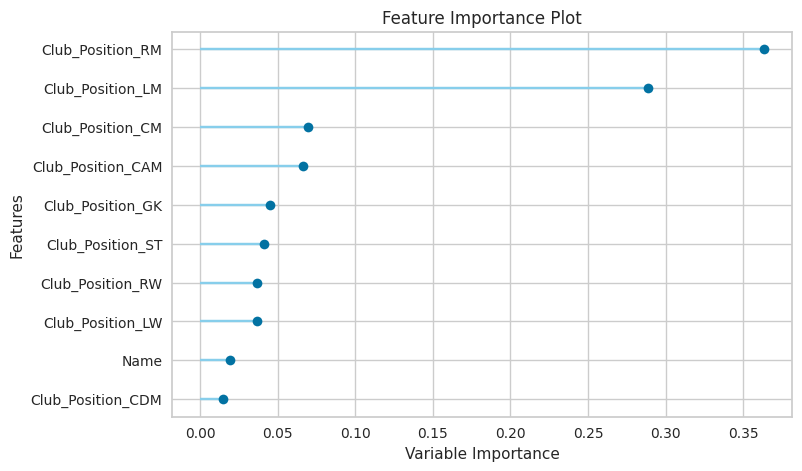

In [13]:
#p3.2.1
xgboost_model = create_model('xgboost')  

#p3.2.2
plot_model(xgboost_model, plot='feature')

In [ ]:
#p3.2.3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb


X = df.drop(columns=['label'])  # Todas las características
y = df['label']  # La columna objetivo

# Codificar variables categóricas usando One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)  # Esto convertirá las columnas categóricas en variables binarias

# Inicializar LabelEncoder
label_encoder = LabelEncoder()

# Ajustar y transformar la variable objetivo
y_encoded = label_encoder.fit_transform(y)

# Dividir el conjunto de datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo XGBoost
xgboost_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgboost_model.fit(X_train, y_train)

# Inicializar RFE con el modelo ya entrenado
rfe = RFE(estimator=xgboost_model, n_features_to_select=1)  # Selecciona una sola característica a la vez

# Ajustar el modelo RFE
rfe.fit(X_train, y_train)

# Obtener las características seleccionadas
selected_features = pd.DataFrame({'Feature': X_train.columns, 'Ranking': rfe.ranking_})

# Filtrar las características seleccionadas
selected_features = selected_features[selected_features['Ranking'] == 1]

print("Características seleccionadas:")
print(selected_features)


In [ ]:
#p3.2.4


In [ ]:
#p3.2.5

### 3.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

In [40]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

# Predecir las probabilidades con el modelo original
y_proba = pipeline_rf.predict_proba(X_test)[:, 1]

# Calcular el Brier Score antes de la calibración
brier_score_before = brier_score_loss(y_test, y_proba)
print(f"Brier Score antes de la calibración: {brier_score_before}")

# Calibrar el modelo
calibrated_model = CalibratedClassifierCV(pipeline_rf, method='sigmoid', cv='prefit')
calibrated_model.fit(X_train, y_train)

# Predecir las probabilidades con el modelo calibrado
y_proba_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Calcular el Brier Score después de la calibración
brier_score_after = brier_score_loss(y_test, y_proba_calibrated)
print(f"Brier Score después de la calibración: {brier_score_after}")

ValueError: Only binary classification is supported. The type of the target is multiclass.